In [1]:
import microarray as ma

In [4]:
gse = "GSE53890"
dataset = ma.datasets.read_geo_metadata(gse, folder="data")

In [5]:
dataset.head()

,sample_geo_accession,sample_name,sample_title,sample_source_name_ch1,sample_organism_ch1,sample_platform_id,sample_series_id,file,file_size,file_url
0,GSM1303144,24_years_old_male,24 years old Male,24 years old Male,Homo sapiens,GPL570,GSE53890,GSM1303144_24M.CEL.gz,8657014,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM1303...
1,GSM1303145,25_years_old_female_2,25 years old Female_2,25 years old Female_2,Homo sapiens,GPL570,GSE53890,GSM1303145_25BF.CEL.gz,8056230,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM1303...
2,GSM1303146,25_years_old_female,25 years old Female,25 years old Female,Homo sapiens,GPL570,GSE53890,GSM1303146_25F.CEL.gz,8441505,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM1303...
3,GSM1303147,26_years_old_male_2,26 years old Male_2,26 years old Male_2,Homo sapiens,GPL570,GSE53890,GSM1303147_26BM.CEL.gz,8337508,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM1303...
4,GSM1303148,26_years_old_male,26 years old Male,26 years old Male,Homo sapiens,GPL570,GSE53890,GSM1303148_26M.CEL.gz,8383414,ftp://ftp.ncbi.nlm.nih.gov/geo/samples/GSM1303...


In [ ]:
# age group annotation
dataset["age"] = dataset["sample_source_name_ch1"].str.split(" ").str[0].astype(float).astype(int)

In [ ]:
def get_age_group(age):
    """Returns the age group for a given age."""
    if age < 40:
        return "young"
    elif age < 70:
        return "middle aged"
    elif age <= 94:
        return "normal aged"
    else:
        return "extremely aged"


dataset["age_group"] = dataset["age"].apply(get_age_group)
dataset["age_group"].value_counts()

age_group
normal aged       16
young             12
middle aged        9
extremely aged     4
Name: count, dtype: int64

In [8]:
adata = ma.datasets.read_geo(
    gse,
    folder="data",
    cdf_file=ma.datasets.hgu133plus2_cdf(),
)
adata

[INFO] [22:00:57] Metadata folder: /home/malte/Dokumente/Github/dtangle/examples/data
[INFO] [22:00:57] Trying GSE53890 (not a file) as accession...
[INFO] [22:00:57] Skipped 0 accessions. Starting now.
[INFO] [22:00:57] Processing accession 1 of 1: 'GSE53890'
[INFO] [22:00:57] Found previous GSE file: /home/malte/Dokumente/Github/dtangle/examples/data/GSE53890_GSE.soft
[INFO] [22:00:57] Found previous GSM file: /home/malte/Dokumente/Github/dtangle/examples/data/GSE53890_GSM.soft
[INFO] [22:00:57] Found previous GSM file: /home/malte/Dokumente/Github/dtangle/examples/data/GSE53890_file_list.txt
[INFO] [22:00:57] 
Total number of processed SAMPLES files found is: 41
[INFO] [22:00:57] Total number of files after filter is: 41 
[INFO] [22:00:57] Total number of processed SERIES files found is: 0
[INFO] [22:00:57] Total number of files after filter is: 0 
[INFO] [22:00:57] Expanding metadata list...
[INFO] [22:00:57] Expanding metadata list...
[INFO] [22:00:57] File /home/malte/Dokumente/G

AnnData object with n_obs × n_vars = 41 × 668466
    obs: 'sample_name', 'cel_version', 'nrows', 'ncols', 'algorithm', 'sample_geo_accession', 'sample_name_meta', 'sample_title', 'sample_source_name_ch1', 'sample_organism_ch1', 'sample_platform_id', 'sample_series_id', 'file', 'file_size', 'file_url'
    var: 'probeset_id', 'probe_index', 'probe_type', 'gene_id', 'suffix'
    layers: 'stdevs', 'npixels', 'masks', 'outliers', 'modified'

In [9]:
ma.pp.normalize_quantile(adata)
ma.pp.log2(adata)

In [10]:
adata_sum = ma.pp.summarize_probesets(adata)

/usr/lib/python3.11/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [13]:
adata_sum = ma.tl.annotate(
    adata_sum,
    remove_unannotated=True,
    set_index=True,
    copy=True,
)
adata_sum.var.head()

,gene_id,n_probes,converged
A1BG,1,16,True
NAT2,10,22,True
ADA,100,40,True
CDH2,1000,38,True
AKT3,10000,130,True


In [48]:
dataset[["age_group", "age", "sample_geo_accession"]].head()

,age_group,age,sample_geo_accession
0,young,24,GSM1303144
1,young,25,GSM1303145
2,young,25,GSM1303146
3,young,26,GSM1303147
4,young,26,GSM1303148


In [56]:
_index = adata_sum.obs.index
_merge_df = adata_sum.obs.merge(
    dataset[["age_group", "age", "sample_geo_accession"]],
    left_on="sample_geo_accession",
    right_on="sample_geo_accession",
    how="left",
)
_merge_df.index = _index
adata_sum.obs = _merge_df

In [14]:
ma.tl.pca(adata_sum)

<Axes: title={'center': 'PCA Plot'}, xlabel='PC1 (29.4%)', ylabel='PC2 (20.5%)'>

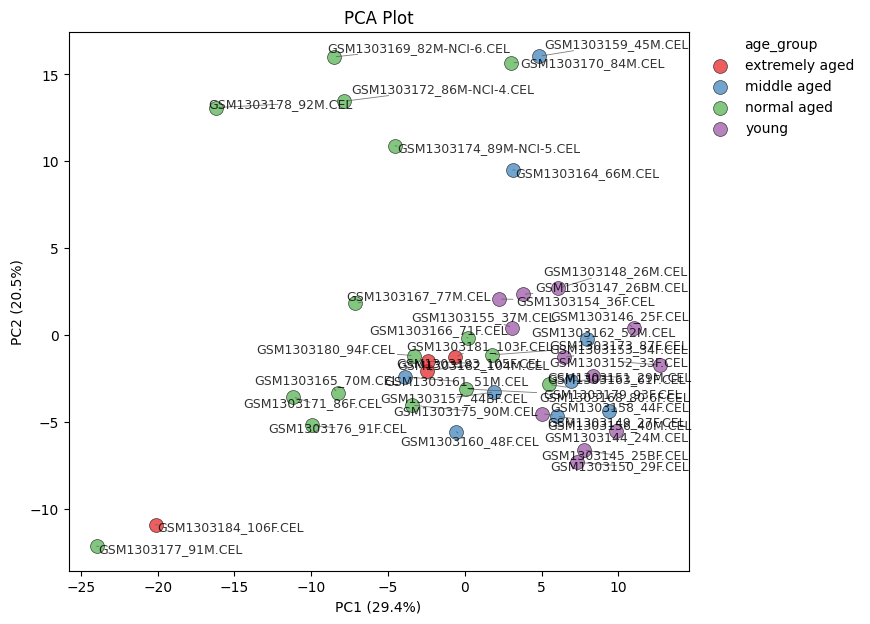

In [61]:
ma.pl.pca(adata_sum, colors="age_group")

In [ ]:
import anndata

anndata.settings.allow_write_nullable_strings = True

In [64]:
adata_sum.write_h5ad("data/brain_aging_microarray.h5ad")